In [1]:
import os 
import tensorflow as tf
import keras
from keras.applications.vgg16 import VGG16,preprocess_input,decode_predictions
from keras.preprocessing.image import load_img, img_to_array
import shutil
import math
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def create_validation_set(directory = "training_set", percentage = 10,val_dir = "validation_set"):
    """
    Creates a validation set by moving the last P% of files from the given directory
    into a subdirectory named 'validation_set'.

    Parameters:
    directory (str): Path to the directory containing the files.
    percentage (float): Percentage (0-100) of files to move.
    """

    # Ensure directory exists
    if not os.path.isdir(directory):
        raise ValueError(f"Directory '{directory}' does not exist.")

    # Get all files in directory (ignore subfolders)
    files = [f for f in os.listdir(directory) 
             if os.path.isfile(os.path.join(directory, f))]

    if not files:
        print("No files found in the directory.")
        return

    # Sort files so "last P%" is deterministic
    files.sort()

    # Number of files to move
    count_to_move = math.ceil(len(files) * (percentage / 100))

    # Select last P%
    files_to_move = files[-count_to_move:]

    # Create validation_set directory
    os.makedirs(val_dir, exist_ok=True)

    # Move files
    for filename in files_to_move:
        src = os.path.join(directory, filename)
        dst = os.path.join(val_dir, filename)
        shutil.move(src, dst)

    print(f"Moved {len(files_to_move)} files to {val_dir}.")


In [7]:
create_validation_set("./training_set/dogs",val_dir="./validation_set/dogs",percentage=20)
create_validation_set("./training_set/cats",val_dir="./validation_set/cats",percentage=20)


Moved 802 files to ./validation_set/dogs.
Moved 801 files to ./validation_set/cats.


# Predict using Pre-Trained Model


In [2]:
img_path = "training_set/cats/cat.1.jpg"
img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array_preprocessed = preprocess_input(img_array)

In [3]:
pretrained_model = VGG16(weights="imagenet")

I0000 00:00:1763327485.599381   20723 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2113 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 851s 2us/step


In [6]:
preds = pretrained_model.predict(img_array_preprocessed)
top_preds = decode_predictions(preds, top=10)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [7]:
print("TOP 10 Predictions: ")
for i,(imgnet_id, label, prob) in enumerate(top_preds):
    print(f"{i+1}. {label:20s} ({prob*100:.2f})")

TOP 10 Predictions: 
1. tabby                (49.12)
2. tiger_cat            (35.41)
3. Egyptian_cat         (7.32)
4. space_heater         (0.49)
5. radiator             (0.45)
6. doormat              (0.43)
7. lynx                 (0.39)
8. carton               (0.31)
9. bucket               (0.25)
10. bookcase             (0.20)


High uncertainity

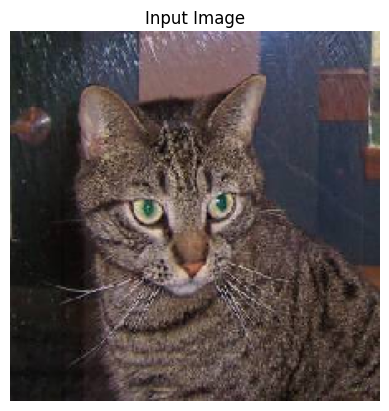

In [8]:
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()